In [1]:
# ============================================
# Task 2: Exploratory Data Analysis (EDA)
# Internship: CodeAlpha
# Name: Hadia Ahad
# Date: June 2026
# Description: EDA on Books dataset scraped
#              from books.toscrape.com
# ============================================

# Import required libraries
import pandas as pd        # For data manipulation
import numpy as np         # For numerical analysis
import matplotlib.pyplot as plt  # For visualization
import seaborn as sns      # For beautiful charts

print("All libraries imported successfully! ✅")

All libraries imported successfully! ✅


In [2]:
# Load the dataset
df = pd.read_csv('books.csv')

# Check shape of data
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (1000, 4)

First 5 rows:


,Title,Price,Rating,Availability
0,A Light in the Attic,Â£51.77,Three,In stock
1,Tipping the Velvet,Â£53.74,One,In stock
2,Soumission,Â£50.10,One,In stock
3,Sharp Objects,Â£47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock


In [3]:
# Check data types and basic info
print("Dataset Info:")
print(df.info())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Title         1000 non-null   object
 1   Price         1000 non-null   object
 2   Rating        1000 non-null   object
 3   Availability  1000 non-null   object
dtypes: object(4)
memory usage: 31.4+ KB
None

Column Names:
['Title', 'Price', 'Rating', 'Availability']

Data Types:
Title           object
Price           object
Rating          object
Availability    object
dtype: object


In [4]:
# Check missing values
print("Missing Values in each column:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing Values in each column:
Title           0
Price           0
Rating          0
Availability    0
dtype: int64

Total missing values: 0

Duplicate rows: 0


In [6]:
# Clean price column - remove any currency symbols
df['Price'] = df['Price'].str.replace('[^0-9.]', '', regex=True).astype(float)

# Verify the change
print("Price column after cleaning:")
print(df['Price'].head())
print("\nData type of Price:", df['Price'].dtype)

Price column after cleaning:
0    51.77
1    53.74
2    50.10
3    47.82
4    54.23
Name: Price, dtype: float64

Data type of Price: float64


In [7]:
# Convert Rating from words to numbers
rating_map = {
    'One': 1,
    'Two': 2,
    'Three': 3,
    'Four': 4,
    'Five': 5
}

# Apply mapping
df['Rating'] = df['Rating'].map(rating_map)

# Verify the change
print("Rating column after cleaning:")
print(df['Rating'].head())
print("\nRating value counts:")
print(df['Rating'].value_counts().sort_index())

Rating column after cleaning:
0    3
1    1
2    1
3    4
4    5
Name: Rating, dtype: int64

Rating value counts:
Rating
1    226
2    196
3    203
4    179
5    196
Name: count, dtype: int64


In [8]:
# Basic statistics of dataset
print("Basic Statistics:")
print(df.describe())

print("\n--- Price Analysis ---")
print("Average Price: £", round(df['Price'].mean(), 2))
print("Highest Price: £", df['Price'].max())
print("Lowest Price: £", df['Price'].min())
print("Median Price: £", df['Price'].median())

print("\n--- Rating Analysis ---")
print("Average Rating:", round(df['Rating'].mean(), 2))
print("Most Common Rating:", df['Rating'].mode()[0])

print("\n--- Availability ---")
print(df['Availability'].value_counts())

Basic Statistics:
            Price       Rating
count  1000.00000  1000.000000
mean     35.07035     2.923000
std      14.44669     1.434967
min      10.00000     1.000000
25%      22.10750     2.000000
50%      35.98000     3.000000
75%      47.45750     4.000000
max      59.99000     5.000000

--- Price Analysis ---
Average Price: £ 35.07
Highest Price: £ 59.99
Lowest Price: £ 10.0
Median Price: £ 35.980000000000004

--- Rating Analysis ---
Average Rating: 2.92
Most Common Rating: 1

--- Availability ---
Availability
In stock    1000
Name: count, dtype: int64


/tmp/ipykernel_22857/515857480.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Rating', data=df, palette='Blues')


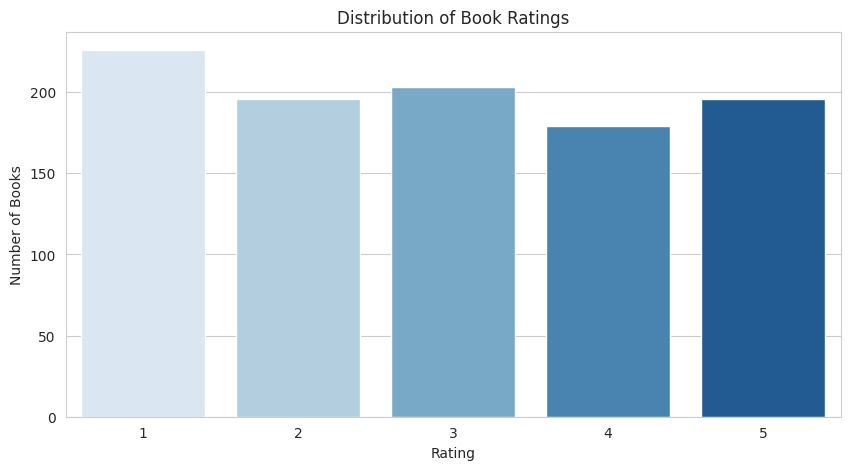

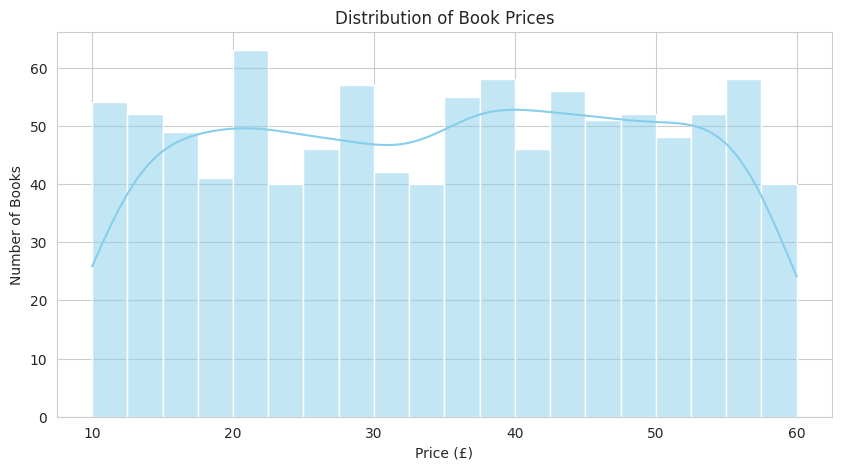

/tmp/ipykernel_22857/515857480.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price.index, y=avg_price.values, palette='coolwarm')


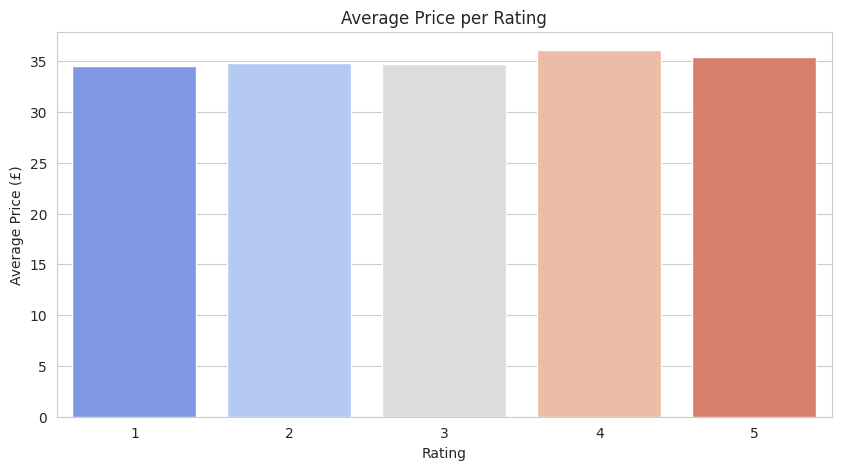

In [9]:
# Set style for all charts
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Chart 1 — Rating Distribution
plt.figure()
sns.countplot(x='Rating', data=df, palette='Blues')
plt.title('Distribution of Book Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Books')
plt.show()

# Chart 2 — Price Distribution
plt.figure()
sns.histplot(df['Price'], bins=20, color='skyblue', kde=True)
plt.title('Distribution of Book Prices')
plt.xlabel('Price (£)')
plt.ylabel('Number of Books')
plt.show()

# Chart 3 — Average Price per Rating
plt.figure()
avg_price = df.groupby('Rating')['Price'].mean()
sns.barplot(x=avg_price.index, y=avg_price.values, palette='coolwarm')
plt.title('Average Price per Rating')
plt.xlabel('Rating')
plt.ylabel('Average Price (£)')
plt.show()

In [10]:
# ============================================
# Key Findings from EDA
# ============================================

print("=" * 50)
print("KEY FINDINGS FROM EDA")
print("=" * 50)

print("\n📚 Dataset Overview:")
print(f"   Total Books: {len(df)}")
print(f"   Total Columns: {len(df.columns)}")
print(f"   Missing Values: {df.isnull().sum().sum()}")

print("\n💰 Price Insights:")
print(f"   Average Price: £{round(df['Price'].mean(), 2)}")
print(f"   Highest Price: £{df['Price'].max()}")
print(f"   Lowest Price: £{df['Price'].min()}")
print(f"   Median Price: £{df['Price'].median()}")

print("\n⭐ Rating Insights:")
print(f"   Average Rating: {round(df['Rating'].mean(), 2)}")
print(f"   Most Common Rating: {df['Rating'].mode()[0]}")
print(f"   Rating Distribution:")
print(df['Rating'].value_counts().sort_index())

print("\n✅ Data Quality:")
print(f"   Missing Values: {df.isnull().sum().sum()}")
print(f"   Duplicate Rows: {df.duplicated().sum()}")
print(f"   Data is Clean and Ready for Analysis!")

print("\n" + "=" * 50)
print("EDA Complete! ✅")
print("=" * 50)

KEY FINDINGS FROM EDA

📚 Dataset Overview:
   Total Books: 1000
   Total Columns: 4
   Missing Values: 0

💰 Price Insights:
   Average Price: £35.07
   Highest Price: £59.99
   Lowest Price: £10.0
   Median Price: £35.980000000000004

⭐ Rating Insights:
   Average Rating: 2.92
   Most Common Rating: 1
   Rating Distribution:
Rating
1    226
2    196
3    203
4    179
5    196
Name: count, dtype: int64

✅ Data Quality:
   Missing Values: 0
   Duplicate Rows: 0
   Data is Clean and Ready for Analysis!

EDA Complete! ✅
